In [13]:
import jax.numpy as jnp
from jax import grad


def funzione(x):
    return x**2 + 3 * x + 12


# Calcolo del gradiente
grad_funzione = grad(funzione)

# Valutazione del gradiente in x = 5.0
x = 5.0
print("Il gradiente in x=5.0 è:", grad_funzione(x))


Il gradiente in x=5.0 è: 13.0


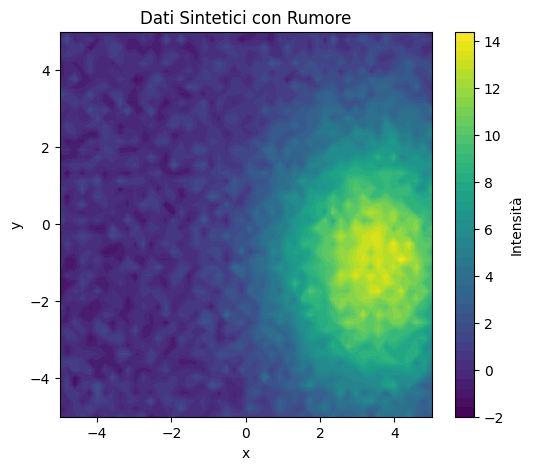

In [49]:
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt

# Chiave casuale per JAX
key = random.PRNGKey(0)

# Generiamo una griglia di punti (x, y)
x = jnp.linspace(-5, 5, 50)
y = jnp.linspace(-5, 5, 50)
x_grid, y_grid = jnp.meshgrid(x, y)

# Parametri veri della Gaussiana
A_true = 13.0
x0_true = 3.5
y0_true = -1
sigma_x_true = 1.9
sigma_y_true = 2.5


# Definiamo la Gaussiana 2D vera
def gaussiana_2d(x, y, A, x0, y0, sigma_x, sigma_y):
    return A * jnp.exp(
        -(((x - x0) ** 2) / (2 * sigma_x**2) + ((y - y0) ** 2) / (2 * sigma_y**2))
    )


# Generiamo i dati con rumore
z_true = gaussiana_2d(
    x_grid, y_grid, A_true, x0_true, y0_true, sigma_x_true, sigma_y_true
)
noise = random.normal(key, z_true.shape) * 0.7  # Rumore gaussiano
z_noisy = z_true + noise

# Visualizziamo i dati sintetici
plt.figure(figsize=(6, 5))
plt.contourf(x_grid, y_grid, z_noisy, levels=50)
plt.colorbar(label="Intensità")
plt.title("Dati Sintetici con Rumore")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [50]:
def loss_function(params, x, y, z_observed):
    A, x0, y0, sigma_x, sigma_y = params
    z_predicted = gaussiana_2d(x, y, A, x0, y0, sigma_x, sigma_y)
    return jnp.mean((z_observed - z_predicted) ** 2)


In [51]:
# Parametri iniziali
params_init = jnp.array([1.0, 0.0, 0.0, 1.0, 1.0])  # [A, x0, y0, sigma_x, sigma_y]

from jax import grad, jit

# Calcolo del gradiente della funzione di perdita
loss_grad = grad(loss_function)


In [52]:
from jax.example_libraries.optimizers import adam

# Impostiamo l'ottimizzatore Adam
learning_rate = .1
opt_init, opt_update, get_params = adam(learning_rate)
opt_state = opt_init(params_init)


@jit
def step(opt_state, x, y, z_observed):
    params = get_params(opt_state)
    value = loss_function(params, x, y, z_observed)
    grads = grad(loss_function)(params, x, y, z_observed)
    opt_state = opt_update(0, grads, opt_state)
    return opt_state, value


# Eseguiamo l'ottimizzazione
num_iterations = 1500
for i in range(num_iterations):
    opt_state, loss_value = step(opt_state, x_grid, y_grid, z_noisy)
    if i % 50 == 0:
        print(f"Iterazione {i}, Loss: {loss_value}")

# Parametri ottimizzati
params_opt = get_params(opt_state)
A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt = params_opt
print("\nParametri ottimizzati:")
print(f"A = {A_opt}")
print(f"x0 = {x0_opt}")
print(f"y0 = {y0_opt}")
print(f"sigma_x = {sigma_x_opt}")
print(f"sigma_y = {sigma_y_opt}")


Iterazione 0, Loss: 21.19123649597168
Iterazione 50, Loss: 2.3518025875091553
Iterazione 100, Loss: 0.6937780976295471
Iterazione 150, Loss: 0.5160595774650574
Iterazione 200, Loss: 0.48714086413383484
Iterazione 250, Loss: 0.48186424374580383
Iterazione 300, Loss: 0.48088544607162476
Iterazione 350, Loss: 0.4807080030441284
Iterazione 400, Loss: 0.48067712783813477
Iterazione 450, Loss: 0.480672150850296
Iterazione 500, Loss: 0.48067137598991394
Iterazione 550, Loss: 0.4806711673736572
Iterazione 600, Loss: 0.4806711673736572
Iterazione 650, Loss: 0.480671226978302
Iterazione 700, Loss: 0.4806711673736572
Iterazione 750, Loss: 0.4806711673736572
Iterazione 800, Loss: 0.48067113757133484
Iterazione 850, Loss: 0.48067113757133484
Iterazione 900, Loss: 0.4806711673736572
Iterazione 950, Loss: 0.48067113757133484
Iterazione 1000, Loss: 0.48067113757133484
Iterazione 1050, Loss: 0.4806711673736572
Iterazione 1100, Loss: 0.48067113757133484
Iterazione 1150, Loss: 0.48067113757133484
Iterazi

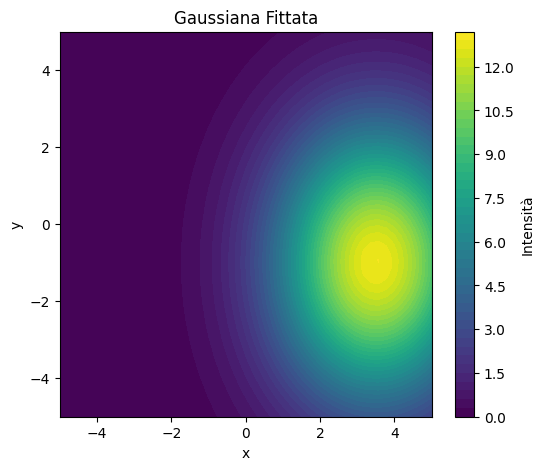

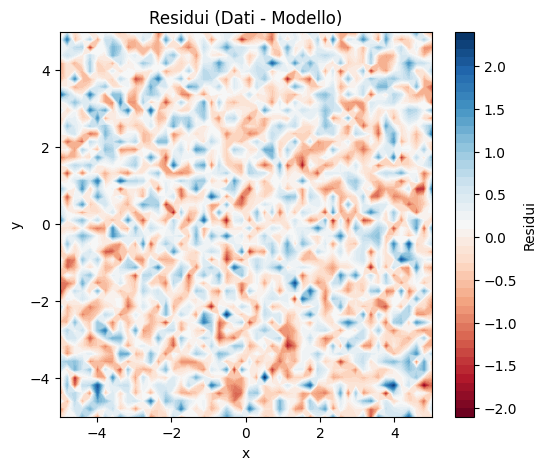

In [53]:
# Calcoliamo la Gaussiana fittata
z_fitted = gaussiana_2d(x_grid, y_grid, A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt)

# Visualizziamo la Gaussiana fittata
plt.figure(figsize=(6, 5))
plt.contourf(x_grid, y_grid, z_fitted, levels=50)
plt.colorbar(label="Intensità")
plt.title("Gaussiana Fittata")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Differenza tra dati osservati e modello fittato
residuals = z_noisy - z_fitted

plt.figure(figsize=(6, 5))
plt.contourf(x_grid, y_grid, residuals, levels=50, cmap="RdBu")
plt.colorbar(label="Residui")
plt.title("Residui (Dati - Modello)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [54]:
print("Parametri Veri:")
print(f"A = {A_true}")
print(f"x0 = {x0_true}")
print(f"y0 = {y0_true}")
print(f"sigma_x = {sigma_x_true}")
print(f"sigma_y = {sigma_y_true}")

print("\nParametri Ottimizzati:")
print(f"A = {A_opt}")
print(f"x0 = {x0_opt}")
print(f"y0 = {y0_opt}")
print(f"sigma_x = {sigma_x_opt}")
print(f"sigma_y = {sigma_y_opt}")


Parametri Veri:
A = 13.0
x0 = 3.5
y0 = -1
sigma_x = 1.9
sigma_y = 2.5

Parametri Ottimizzati:
A = 12.915665626525879
x0 = 3.5124711990356445
y0 = -0.9944027066230774
sigma_x = 1.9092010259628296
sigma_y = 2.5078861713409424
